# Part 1 — Qiskit Fundamentals

**Goals of this notebook.** Build, and rigorously justify, the basic objects of gate-based
quantum computing: single-qubit superposition, the measurement (Born-rule) postulate, and the
two canonical multi-qubit entangled states (Bell, GHZ). Every circuit here is built from the
reusable functions in `src/circuits.py`, executed via `src/simulation.py`, and plotted via
`src/visualization.py` — nothing is constructed ad hoc in this notebook.

This assumes comfort with linear algebra, probability, and measure theory, and deliberately does
**not** oversimplify the math. What's new relative to that background is: (1) the specific
Hilbert-space bookkeeping conventions (tensor-product qubit ordering, Dirac notation), and (2)
the measurement postulate, which is a genuinely new axiom — not derivable from unitary evolution
alone.

In [1]:
import numpy as np
from qiskit.quantum_info import Statevector, partial_trace
from qiskit.visualization import plot_bloch_multivector

from src.circuits import single_qubit_superposition, uniform_superposition, bell_state, ghz_state
from src.simulation import (
    get_statevector,
    sample_counts,
    probabilities_from_counts,
    theoretical_probabilities,
)
from src.visualization import plot_counts_histogram, plot_probability_comparison

np.set_printoptions(precision=4, suppress=True)

## 1. Single-qubit superposition and the Hadamard gate

**Explain.** A qubit's state space is $\mathbb{C}^2$ with computational basis
$|0\rangle=\begin{pmatrix}1\\0\end{pmatrix}$, $|1\rangle=\begin{pmatrix}0\\1\end{pmatrix}$. A
general pure state is $|\psi\rangle=\alpha|0\rangle+\beta|1\rangle$ with $\alpha,\beta\in\mathbb C$,
$|\alpha|^2+|\beta|^2=1$ — a unit vector in $\mathbb C^2$. As established in
`docs/interview_questions.md` (Q1), the *physical* state space further quotients by global phase,
giving the projective space $\mathbb{CP}^1$, which is isomorphic to the Bloch sphere $S^2$.

**Derive.** The Hadamard gate is $H=\frac{1}{\sqrt2}\begin{pmatrix}1&1\\1&-1\end{pmatrix}$. Two
algebraic facts worth internalizing: $H=H^\dagger$ (Hermitian) and $H^2=I$ (so $H$ is its own
inverse — it's an involution, not just unitary). Applying it to the basis states:
$$H|0\rangle=\frac{|0\rangle+|1\rangle}{\sqrt2}, \qquad H|1\rangle=\frac{|0\rangle-|1\rangle}{\sqrt2}.$$
On the Bloch sphere, $H$ is a $\pi$ rotation about the axis $(\hat x+\hat z)/\sqrt2$ — a concrete
geometric picture for what is otherwise just a $2\times2$ unitary.

More generally, any point on the Bloch sphere is reachable via
$|\psi(\theta,\varphi)\rangle=\cos\frac{\theta}{2}|0\rangle+e^{i\varphi}\sin\frac{\theta}{2}|1\rangle$
— this is exactly what `single_qubit_superposition(theta, phi)` implements via the Qiskit `U`
gate, so we can probe arbitrary points, not just $H|0\rangle$.

**Implement.**

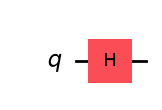

In [2]:
h_qc = uniform_superposition(1)
h_qc.draw("mpl")

In [3]:
h_sv = get_statevector(h_qc)
print("H|0> statevector:", h_sv.data)

H|0> statevector: [0.7071+0.j 0.7071+0.j]


**Visualize.**

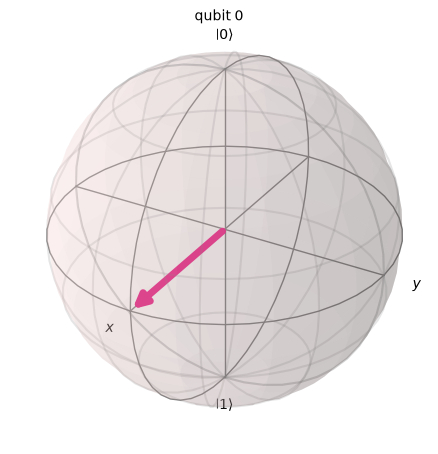

In [4]:
plot_bloch_multivector(h_sv)

General point statevector: [0.866 +0.j     0.3536+0.3536j]


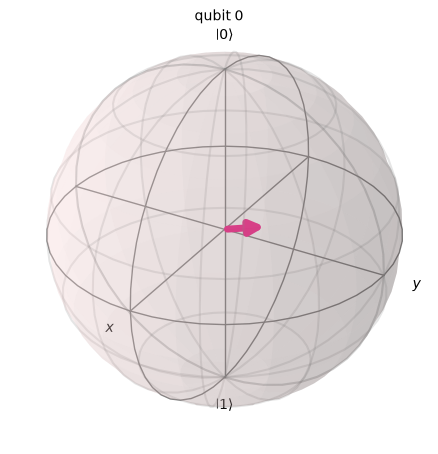

In [5]:
theta, phi = np.pi / 3, np.pi / 4
general_qc = single_qubit_superposition(theta, phi)
general_sv = get_statevector(general_qc)
print("General point statevector:", general_sv.data)
plot_bloch_multivector(general_sv)

**Summarize.** Superposition itself is nothing exotic — it's just a vector expressed in a basis,
identical in spirit to writing $v = v_x\hat x + v_y\hat y$ in ordinary linear algebra. The genuinely
new physical content shows up next, in how we're allowed to *extract information* from that vector.

## 2. Measurement and the Born rule

**Explain.** Given $|\psi\rangle=\sum_i c_i|i\rangle$ in some orthonormal basis $\{|i\rangle\}$,
measuring in that basis yields outcome $i$ with probability $P(i)=|c_i|^2=|\langle i|\psi\rangle|^2$
— the Born rule. Equivalently, with projector $\Pi_i=|i\rangle\langle i|$,
$P(i)=\langle\psi|\Pi_i|\psi\rangle$, since $\Pi_i$ is an idempotent Hermitian operator. This is
worth connecting explicitly to measure theory: $\{\Pi_i\}$ is a projection-valued measure (a
special case of a POVM — the general object is $\{E_i\}$ with $E_i\succeq0$, $\sum_i E_i=I$, not
necessarily projectors; POVMs will matter once we model noisy/imperfect measurements). The map
$i \mapsto \langle\psi|\Pi_i|\psi\rangle$ is a genuine probability measure on the finite outcome
space: nonnegative, and $\sum_i P(i) = \langle\psi|\big(\sum_i\Pi_i\big)|\psi\rangle=\langle\psi|\psi\rangle=1$.

**Derive — finite-shot statistics.** A real device (or simulator) only ever returns a finite
sample of $N$ measurement outcomes, i.e. an i.i.d. draw from the multinomial distribution with
probabilities $P(i)$. The empirical frequency $\hat P(i) = (\text{count}_i)/N$ is an unbiased
estimator of $P(i)$ with standard error $\sqrt{P(i)(1-P(i))/N} = O(1/\sqrt N)$. This is exactly
why `tests/test_circuits.py` uses a loose $\pm10\%$ tolerance on a $\pm 50\%$ split rather than
exact equality — asserting exact equality of a finite-sample frequency against a continuous
probability is a category error.

**Implement.**

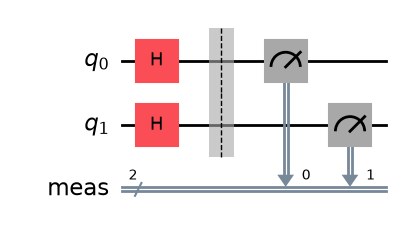

In [6]:
qc2 = uniform_superposition(2, measure=True)
qc2.draw("mpl")

In [7]:
counts = sample_counts(qc2, shots=4096, seed=1)
empirical = probabilities_from_counts(counts)
theoretical = theoretical_probabilities(uniform_superposition(2))
print("counts:", counts)
print("empirical:", empirical)
print("theoretical:", theoretical)

counts: {'10': 1029, '00': 1004, '01': 1040, '11': 1023}
empirical: {'10': 0.251220703125, '00': 0.2451171875, '01': 0.25390625, '11': 0.249755859375}
theoretical: {np.str_('00'): np.float64(0.2499999999999999), np.str_('01'): np.float64(0.2499999999999999), np.str_('10'): np.float64(0.2499999999999999), np.str_('11'): np.float64(0.2499999999999999)}


**Visualize.**

<Axes: title={'center': '2-qubit uniform superposition — raw counts'}, xlabel='Measured bitstring', ylabel='Counts'>

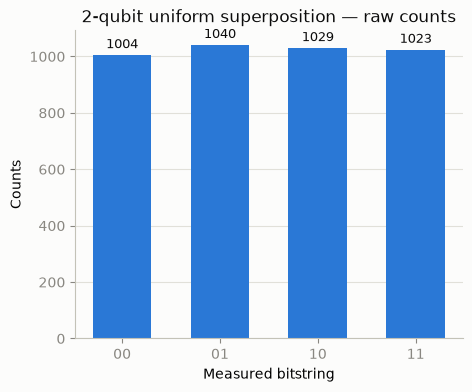

In [8]:
plot_counts_histogram(counts, title="2-qubit uniform superposition — raw counts")

<Axes: title={'center': 'Empirical vs theoretical probabilities'}, xlabel='Measured bitstring', ylabel='Probability'>

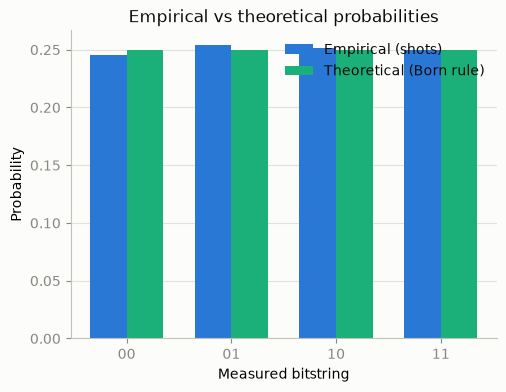

In [9]:
plot_probability_comparison(empirical, theoretical, title="Empirical vs theoretical probabilities")

**Derive, empirically — the $O(1/\sqrt N)$ shrinkage.** Sample the same circuit at increasing shot
counts and track total $L_1$ error against the exact uniform distribution ($0.25$ per outcome):

In [10]:
shot_counts = [16, 64, 256, 1024, 4096, 16384]
for shots in shot_counts:
    c = sample_counts(uniform_superposition(2, measure=True), shots=shots, seed=7)
    p = probabilities_from_counts(c)
    l1_error = sum(abs(p.get(b, 0.0) - 0.25) for b in ["00", "01", "10", "11"])
    print(f"shots={shots:>6}   L1 error={l1_error:.4f}   ~1/sqrt(shots)={1/np.sqrt(shots):.4f}")

shots=    16   L1 error=0.2500   ~1/sqrt(shots)=0.2500
shots=    64   L1 error=0.1562   ~1/sqrt(shots)=0.1250
shots=   256   L1 error=0.1094   ~1/sqrt(shots)=0.0625
shots=  1024   L1 error=0.0527   ~1/sqrt(shots)=0.0312
shots=  4096   L1 error=0.0249   ~1/sqrt(shots)=0.0156


shots= 16384   L1 error=0.0084   ~1/sqrt(shots)=0.0078


**Summarize.** Measurement is where classical probability enters quantum mechanics: an exact,
deterministic linear-algebra object (the statevector) becomes a stochastic sample the moment we
ask a question of it. Finite-shot estimation is textbook multinomial sampling — nothing about
"quantumness" changes the statistics of *counting*, only where the underlying probabilities
$P(i)$ come from.

## 3. The Bell state and entanglement

**Explain — separability.** For a bipartite system $\mathcal H_A\otimes\mathcal H_B$, a pure state
$|\psi\rangle$ is *separable* (product, unentangled) if $|\psi\rangle=|a\rangle\otimes|b\rangle$
for some $|a\rangle\in\mathcal H_A$, $|b\rangle\in\mathcal H_B$, and *entangled* otherwise. The
precise tool for this is the **Schmidt decomposition**: every bipartite pure state can be written
$|\psi\rangle=\sum_k\lambda_k|a_k\rangle|b_k\rangle$ with $\lambda_k\ge0$, $\sum_k\lambda_k^2=1$,
and $\{|a_k\rangle\},\{|b_k\rangle\}$ orthonormal. The state is separable iff the Schmidt rank
(number of nonzero $\lambda_k$) is $1$.

**Derive — the Bell state $|\Phi^+\rangle$.** Built via $H(0)$ then $\mathrm{CX}(0,1)$:
$$|00\rangle \xrightarrow{H\otimes I} \frac{|00\rangle+|10\rangle}{\sqrt2}
\xrightarrow{\mathrm{CX}} \frac{|00\rangle+|11\rangle}{\sqrt2} = |\Phi^+\rangle.$$
Its Schmidt coefficients are $\lambda_1=\lambda_2=1/\sqrt2$ — maximal entanglement, the largest
Schmidt rank two qubits admit.

**Derive — the reduced density matrix.** The precise fingerprint of entanglement: compute
$\rho_A=\mathrm{Tr}_B(|\Phi^+\rangle\langle\Phi^+|)$ (the partial trace over qubit $B$). For
$|\Phi^+\rangle$ this gives $\rho_A = I/2$ — the maximally mixed single-qubit state. This is the
sharp quantum/classical contrast worth having ready for an interview: classically, if a joint
distribution over $(A,B)$ has zero entropy (i.e. is a deterministic, known outcome), its marginals
must also have zero entropy — $H(A,B)=0 \Rightarrow H(A)=H(B)=0$. Here the *global* state is pure
(zero von Neumann entropy, $S(\rho_{AB})=0$ since $\rho_{AB}$ is rank-1), yet each *local* reduced
state has **maximal** entropy. That gap — a globally pure state with maximally mixed marginals —
has no classical analogue and is exactly what "entanglement" means operationally.

Note also: the partial trace is a completely-positive, trace-preserving (CPTP) map — the same
category of object we'll use in Part 2 to define noise channels. Losing access to a subsystem and
suffering physical noise are mathematically the same kind of operation.

**Implement.**

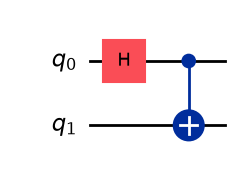

In [11]:
phi_plus = bell_state("phi_plus")
phi_plus.draw("mpl")

In [12]:
bell_sv = get_statevector(phi_plus)
print("Bell statevector:", bell_sv.data)

rho_A = partial_trace(bell_sv, [1])  # trace out qubit 1, keep qubit 0
print("\nReduced density matrix rho_A = Tr_B(|Phi+><Phi+|):")
print(rho_A.data)

Bell statevector: [0.7071+0.j 0.    +0.j 0.    +0.j 0.7071+0.j]

Reduced density matrix rho_A = Tr_B(|Phi+><Phi+|):
[[0.5+0.j 0. +0.j]
 [0. +0.j 0.5+0.j]]


**A Qiskit-specific gotcha worth flagging explicitly:** Qiskit orders qubits with qubit 0 as the
*least-significant* bit, so a printed bitstring like `"01"` means $q_1{=}0, q_0{=}1$ — the
opposite of the order you'd naively read left-to-right against qubit indices. It's a frequent
source of off-by-reversal bugs; `partial_trace`'s qubit-index argument above (`[1]`) refers to
*qubit index*, not string position, which sidesteps the issue here but won't always.

**Visualize.**

<Axes: title={'center': 'Bell state |Phi+> - measurement outcomes'}, xlabel='Measured bitstring', ylabel='Counts'>

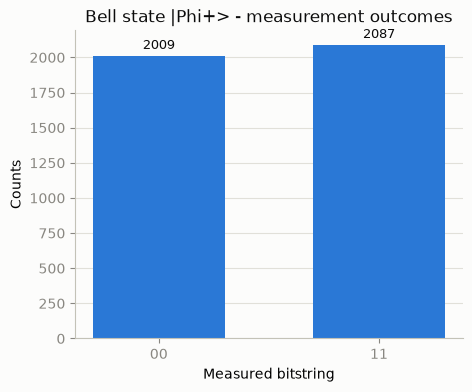

In [13]:
bell_counts = sample_counts(bell_state("phi_plus", measure=True), shots=4096, seed=42)
plot_counts_histogram(bell_counts, title="Bell state |Phi+> - measurement outcomes")

**Summarize.** Entanglement = non-separability = Schmidt rank $>1$. Its operational signature is
that a pure global state can have mixed local parts — impossible classically. The same
partial-trace machinery used to reveal this is, mathematically, the same machinery that will
define noise channels in Part 2 (decoherence *is*, physically, entanglement with an unmeasured
environment followed by tracing that environment out).

## 4. The GHZ state — multipartite entanglement, and its fragility

**Explain.** The Bell state generalizes to $n$ qubits as
$$|\mathrm{GHZ}_n\rangle = \frac{|0\cdots0\rangle + |1\cdots1\rangle}{\sqrt2},$$
built by one Hadamard followed by a chain of CNOTs from qubit 0 to every other qubit. This is
*genuine multipartite* entanglement — it cannot be reduced to a collection of pairwise Bell pairs.

**Derive — two different partial traces, two different lessons.** Take $|\mathrm{GHZ}_3\rangle$
on qubits $(0,1,2)$.

- Trace out *two* qubits, keep one: $\rho_0=\mathrm{Tr}_{1,2}(|\mathrm{GHZ}_3\rangle\langle\cdot|)=I/2$
  — maximally mixed, same as the Bell-state case. A single qubit alone can never show
  "correlation" (that needs $\ge2$ parties), so this only demonstrates local mixedness again.
- Trace out *one* qubit, keep two: $\rho_{01}=\mathrm{Tr}_2(|\mathrm{GHZ}_3\rangle\langle\cdot|)
  = \frac{1}{2}\big(|00\rangle\langle00| + |11\rangle\langle11|\big)$ — a **classical mixture**.
  The off-diagonal coherence term $|00\rangle\langle11|$ vanishes because it requires
  $\langle 0|1\rangle$ on the traced-out qubit, which is $0$. The two remaining qubits are still
  perfectly *correlated* (always agree), but that correlation is now entirely classical —
  indistinguishable from "flip a fair coin, then copy the result to two parties."

This is GHZ's defining fragility: losing access to **any single qubit** destroys all quantum
coherence in the rest, immediately, leaving behind only classical correlation. Compare to a Bell
pair, where there's nothing left to lose partial access to without destroying the pair entirely.
This asymmetry — how gracefully different entangled states degrade under qubit loss — is a direct
preview of why maintaining large entangled states on noisy hardware is hard, and it's the reason
GHZ-state fidelity is a standard benchmark for how much noise a device has (Part 3).

**Implement.**

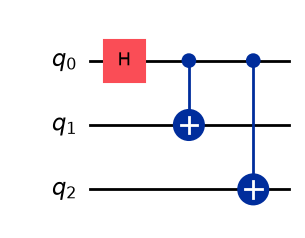

In [14]:
ghz3 = ghz_state(3)
ghz3.draw("mpl")

In [15]:
ghz_sv = get_statevector(ghz3)
print("GHZ(3) statevector:", ghz_sv.data)

GHZ(3) statevector: [0.7071+0.j 0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j
 0.    +0.j 0.7071+0.j]


In [16]:
rho_0 = partial_trace(ghz_sv, [1, 2])   # trace out qubits 1,2 -> keep qubit 0 alone
rho_01 = partial_trace(ghz_sv, [2])     # trace out qubit 2 only -> keep qubits 0,1

print("rho_0 (trace out 2 of 3 qubits, maximally mixed):")
print(rho_0.data)
print("\nrho_01 (trace out 1 of 3 qubits, classical mixture -- off-diagonals vanish):")
print(rho_01.data)

rho_0 (trace out 2 of 3 qubits, maximally mixed):
[[0.5+0.j 0. +0.j]
 [0. +0.j 0.5+0.j]]

rho_01 (trace out 1 of 3 qubits, classical mixture -- off-diagonals vanish):
[[0.5+0.j 0. +0.j 0. +0.j 0. +0.j]
 [0. +0.j 0. +0.j 0. +0.j 0. +0.j]
 [0. +0.j 0. +0.j 0. +0.j 0. +0.j]
 [0. +0.j 0. +0.j 0. +0.j 0.5+0.j]]


**Visualize.**

<Axes: title={'center': 'GHZ(3) - measurement outcomes'}, xlabel='Measured bitstring', ylabel='Counts'>

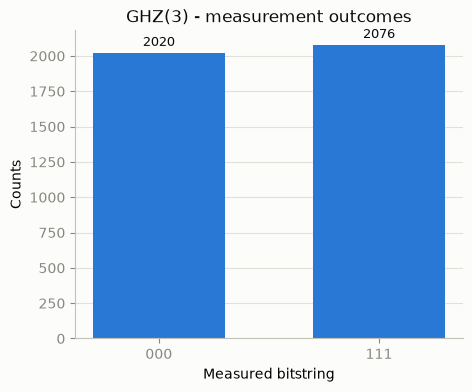

In [17]:
ghz_counts = sample_counts(ghz_state(3, measure=True), shots=4096, seed=42)
plot_counts_histogram(ghz_counts, title="GHZ(3) - measurement outcomes")

**Summarize.** Multipartite entanglement isn't just "more" of the bipartite kind — it has
structure that determines exactly how a state degrades under partial information loss. GHZ states
are maximally fragile in this sense (any single-qubit loss kills all remaining coherence); this
sets up the natural question for Part 2: *how does that fragility play out under a realistic,
imperfect (probabilistic, not "trace out a qubit") noise process?*

## 5. Summary and hand-off

Covered in this notebook, each following explain → derive → implement → visualize → summarize:

1. Single-qubit superposition, the Hadamard gate, and the Bloch-sphere picture.
2. The measurement postulate (Born rule), its measure-theoretic reading as a projection-valued
   measure, and the $O(1/\sqrt N)$ finite-shot estimation error.
3. The Bell state, the Schmidt decomposition, and the reduced-density-matrix signature of
   entanglement (global purity with maximal local mixedness — impossible classically).
4. The GHZ state, genuine multipartite entanglement, and why it degrades more catastrophically
   than a Bell pair under loss of a single qubit.

All conceptual questions and answers that came up while building this (global vs. relative phase,
the Born rule as a measure, Schmidt decomposition / entanglement fingerprint, Qiskit's
little-endian qubit ordering, GHZ fragility) are logged in `docs/interview_questions.md` for
interview review — that file is the place to revisit these without re-deriving them from scratch.

**Next milestone (not started here):** Part 2 — quantum noise models (bit flip, phase flip,
depolarizing, amplitude damping, phase damping), each via their Kraus-operator representation.